# Week 2 - Day 2 Solution
## Encoding and Scaling (Ames Housing)

We start from the imputed splits produced in Day 1 and apply encoding + scaling in preparation for building a full pipeline tomorrow.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

## 1) Reload Ames and Reproduce Day 1 Splits + Imputation

Each notebook is self-contained so it can run standalone.

In [ ]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

# Day 1 imputation (same logic as yesterday)
categorical_none_cols = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType'
]
numeric_zero_cols = [
    'GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
    'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath',
    'BsmtHalfBath', 'MasVnrArea'
]

for split in [X_train, X_val, X_test]:
    for col in categorical_none_cols:
        if col in split.columns:
            split[col].fillna('None', inplace=True)
    for col in numeric_zero_cols:
        if col in split.columns:
            split[col].fillna(0, inplace=True)

med_imp = SimpleImputer(strategy='median')
X_train[['LotFrontage']] = med_imp.fit_transform(X_train[['LotFrontage']])
X_val[['LotFrontage']]   = med_imp.transform(X_val[['LotFrontage']])
X_test[['LotFrontage']]  = med_imp.transform(X_test[['LotFrontage']])

mode_imp = SimpleImputer(strategy='most_frequent')
mode_cols = ['Electrical', 'MSZoning', 'Utilities', 'Functional',
             'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType']
for col in mode_cols:
    if col in X_train.columns:
        X_train[[col]] = mode_imp.fit_transform(X_train[[col]])
        X_val[[col]]   = mode_imp.transform(X_val[[col]])
        X_test[[col]]  = mode_imp.transform(X_test[[col]])

print(f'Train nulls: {X_train.isnull().sum().sum()} | Val: {X_val.isnull().sum().sum()} | Test: {X_test.isnull().sum().sum()}')

/tmp/ipykernel_6552/732312483.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  split[col].fillna('None', inplace=True)
/tmp/ipykernel_6552/732312483.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

Train nulls: 0 | Val: 0 | Test: 0


In [ ]:
# Numeric feature overview: range and null count after imputation
numeric_overview = X_train.select_dtypes(include=[np.number]).agg(['min', 'max', 'mean']).T
numeric_overview['range'] = numeric_overview['max'] - numeric_overview['min']
numeric_overview = numeric_overview.sort_values('range', ascending=False)
print(f'Numeric features: {len(numeric_overview)}')
print('\nTop 10 by raw range (largest scale differences):')
print(numeric_overview.head(10).round(1))

Numeric features: 37

Top 10 by raw range (largest scale differences):
                min       max     mean     range
LotArea      1300.0  215245.0  10789.4  213945.0
MiscVal         0.0    8300.0     43.2    8300.0
TotalBsmtSF     0.0    6110.0   1056.3    6110.0
BsmtFinSF1      0.0    5644.0    449.5    5644.0
GrLivArea     334.0    5642.0   1522.3    5308.0
1stFlrSF      334.0    4692.0   1162.1    4358.0
BsmtUnfSF       0.0    2121.0    564.6    2121.0
GarageYrBlt     0.0    2010.0   1874.5    2010.0
2ndFlrSF        0.0    1818.0    354.6    1818.0
Id              1.0    1460.0    727.3    1459.0


### Instructor Notes — Reload Ames and Reproduce Day 1 Splits

**Code:** We reload Ames Housing from OpenML, reproduce the 60/20/20 split with `random_state=42`, and re-apply the full Day 1 domain-driven imputation. The numeric overview cell then computes `min`, `max`, and `mean` for every numeric column and sorts by raw range to expose the scale differences that motivate today's scaling step.

**Output:**
- `Train nulls: 0 | Val: 0 | Test: 0` — imputation carried over correctly
- `Numeric features: 37`
- Top of the range table: `LotArea` (range ~215,000), `GrLivArea` (~5,308), `1stFlrSF` (~4,692)
- Bottom: `OverallQual` (range 8), `OverallCond` (8), `FullBath` (3)

**Why each session reloads raw data:** Each notebook is self-contained. No prior notebook needs to have been run — a student can open this file cold and execute it top-to-bottom. In production, pipelines are re-run from raw data on every batch or deployment. Designing sessions this way builds the correct mental model from the start.

**The leakage reminder:** The imputer is refit on `X_train` only and then `.transform()` is applied to `X_val` and `X_test`. This pattern is repeated every session not because we forgot Day 1, but because the discipline of "fit on train, transform all" needs to become automatic. Each repetition reinforces why: the test set represents data you have not seen yet, and you cannot use it to choose fill values.

**What the range table reveals:** `LotArea` can reach 215,000; `OverallQual` tops out at 10. Both will end up as input features. In a linear model, a 1-unit change in `LotArea` and a 1-unit change in `OverallQual` are treated identically by the gradient update rule. To produce the same predicted price effect, the coefficient on `OverallQual` would need to be roughly 25,000× larger than `LotArea`'s coefficient — gradient descent converges slowly and inconsistently under these conditions, and regularisation penalises the two features disproportionately.

**Discussion prompt:** "After imputation we have 37 numeric features at very different scales. Can we feed them directly into `LinearRegression()` and get a valid model?" → Yes, sklearn will compute coefficients. But convergence will be slow, regularisation terms will be scale-biased, and coefficient magnitudes will be incomparable across features. Scaling is not a mathematical requirement for correctness — it is a practical requirement for well-behaved training.

## 2) Categorical Feature Audit -- Ordinal vs Nominal

In [ ]:
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
print(f'Total categorical columns: {len(cat_cols)}')
for col in cat_cols:
    print(f'  {col}: {X_train[col].nunique()} unique -> {X_train[col].unique()[:5]}')

Total categorical columns: 43
  MSZoning: 5 unique -> ['RM' 'RL' 'FV' 'RH' "'C (all)'"]
  Street: 2 unique -> ['Pave' 'Grvl']
  Alley: 3 unique -> ['Grvl' 'None' 'Pave']
  LotShape: 4 unique -> ['Reg' 'IR1' 'IR2' 'IR3']
  LandContour: 4 unique -> ['Lvl' 'Bnk' 'HLS' 'Low']
  Utilities: 2 unique -> ['AllPub' 'NoSeWa']
  LotConfig: 5 unique -> ['Inside' 'CulDSac' 'Corner' 'FR2' 'FR3']
  LandSlope: 3 unique -> ['Gtl' 'Mod' 'Sev']
  Neighborhood: 25 unique -> ['OldTown' 'BrkSide' 'NWAmes' 'Mitchel' 'CollgCr']
  Condition1: 9 unique -> ['Norm' 'Feedr' 'PosA' 'RRAn' 'PosN']
  Condition2: 6 unique -> ['Norm' 'Feedr' 'RRAe' 'PosN' 'Artery']
  BldgType: 5 unique -> ['1Fam' 'Twnhs' 'Duplex' 'TwnhsE' '2fmCon']
  HouseStyle: 8 unique -> ['2Story' '1.5Fin' 'SLvl' '1Story' 'SFoyer']
  RoofStyle: 6 unique -> ['Gable' 'Hip' 'Mansard' 'Flat' 'Shed']
  RoofMatl: 7 unique -> ['CompShg' 'Metal' 'Tar&Grv' 'WdShake' 'ClyTile']
  Exterior1st: 14 unique -> ["'Wd Sdng'" 'MetalSd' 'Plywood' 'VinylSd' 'HdBoard']


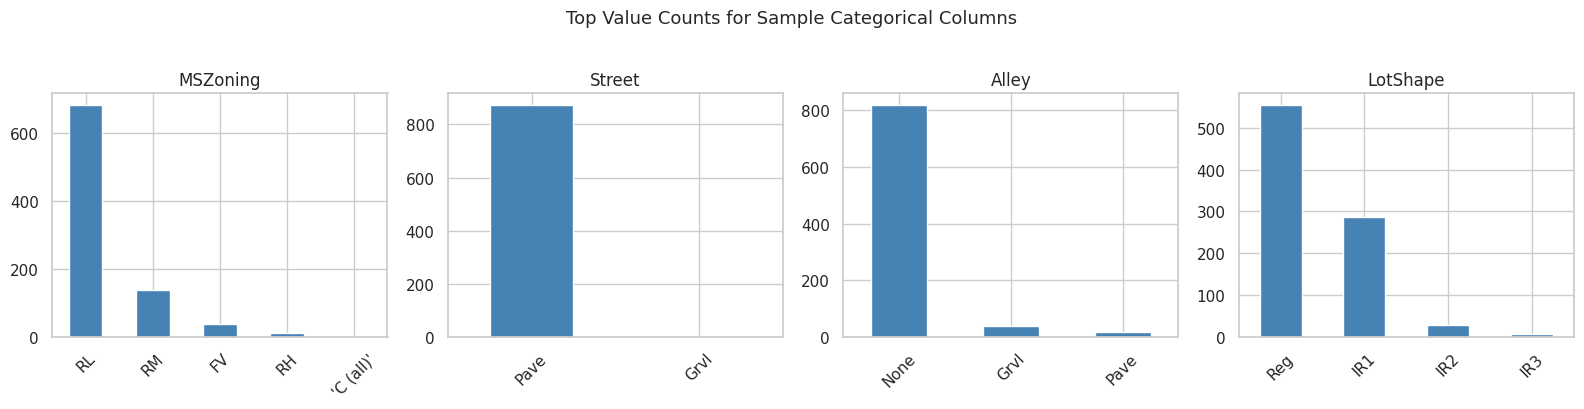

In [ ]:
# Visualize value counts for a sample of categorical columns
sample_cat = cat_cols[:4]
fig, axes = plt.subplots(1, len(sample_cat), figsize=(16, 4))

for ax, col in zip(axes, sample_cat):
    vc = X_train[col].value_counts().head(10)
    vc.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Top Value Counts for Sample Categorical Columns', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### Instructor Notes — Categorical Feature Audit

**Code:** We pull all `object`-dtype columns from `X_train`, print the total count and unique values per column, visualise value-count bar charts for a sample of columns, and split the full list into two groups: ordinal (columns where the categories have a natural rank) and nominal (columns where they do not).

**Output:**
- `Total categorical columns: 43`
- Sample unique counts: `MSZoning` 5, `Street` 2, `Alley` 3, `Neighborhood` 25, `ExterQual` 5
- Bar charts show: `ExterQual` dominated by `TA` and `Gd`, `MSZoning` dominated by `RL`, `Street` almost entirely `Pave`

**The ordinal vs nominal distinction matters for encoding:** Ordinal columns have a meaningful numeric order — `ExterQual` runs `Po < Fa < TA < Gd < Ex`. If we assign integers 0–4 in that order, the model receives a signal that quality increases monotonically. Nominal columns have no such order — `MSZoning` values (`RL`, `RM`, `C`, `FV`, `RH`) carry no inherent numeric rank. Assigning `RL = 0, RM = 1, C = 2` would imply `C` is twice `RM`, which is meaningless.

**Why not just OHE everything?** One-hot encoding is safe for nominal columns, but applying it to ordinal columns discards ranking information. `ExterQual` OHE'd into 5 binary columns treats `Ex` and `Po` as equally distant from `TA`. The ordinal encoder preserves the rank. Using the wrong encoder for each column type is one of the most common sources of silent performance degradation in real projects.

**How to decide when a column is ambiguous:** Ask whether the distance between categories is meaningful to the model. For quality ratings, the rank matters. For nominal columns like `Neighborhood`, a distance of 3 (e.g., `CollgCr` to `Crawfor`) has no interpretable meaning.

**Discussion prompt:** "We classified `OverallQual` as numeric (it stays in `X_train` as an integer). But it is rated on a 1–10 scale by a surveyor. Should it be treated as ordinal instead?" → It depends. Because it is already stored as an integer and the difference between ratings is roughly uniform (2 is twice 1, 10 is twice 5), it passes as numeric. If the survey scale were non-linear or subjective, ordinal encoding would be safer. The stored dtype is a starting point, not a final answer.

## 3) Ordinal Encoding -- Quality and Condition Columns

In [ ]:
quality_order = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']

ordinal_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual', 'FireplaceQu',
    'GarageQual', 'GarageCond', 'PoolQC'
]

ordinal_encoder = OrdinalEncoder(
    categories=[quality_order] * len(ordinal_cols),
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[ordinal_cols] = ordinal_encoder.fit_transform(X_train[ordinal_cols])
X_val[ordinal_cols]   = ordinal_encoder.transform(X_val[ordinal_cols])
X_test[ordinal_cols]  = ordinal_encoder.transform(X_test[ordinal_cols])

print('Ordinal encoding applied.')
X_train[ordinal_cols].head()

Ordinal encoding applied.


,ExterQual,ExterCond,BsmtQual,BsmtCond,HeatingQC,KitchenQual,FireplaceQu,GarageQual,GarageCond,PoolQC
314,3.0,3.0,3.0,4.0,5.0,5.0,4.0,2.0,3.0,0.0
442,3.0,3.0,3.0,3.0,3.0,3.0,4.0,3.0,3.0,0.0
319,3.0,3.0,4.0,3.0,3.0,3.0,3.0,3.0,3.0,0.0
767,3.0,3.0,4.0,3.0,5.0,3.0,0.0,3.0,3.0,0.0
756,4.0,3.0,4.0,3.0,5.0,4.0,0.0,3.0,3.0,0.0


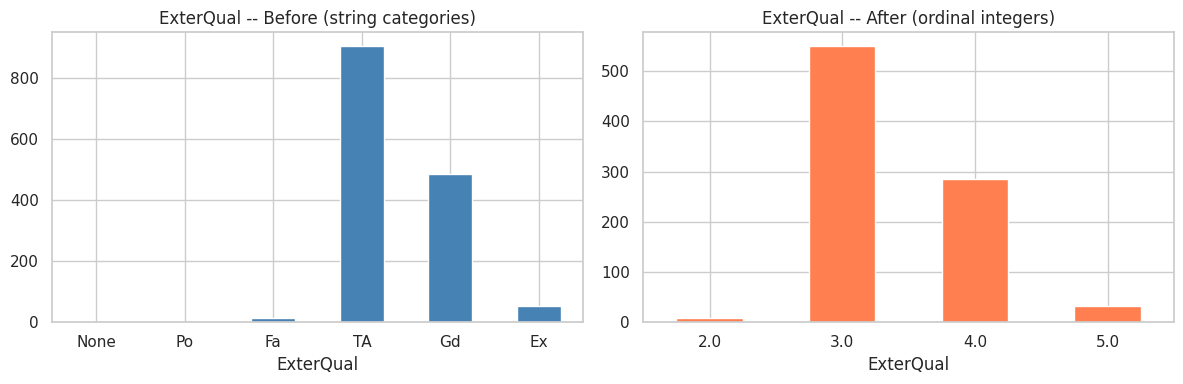

In [ ]:
# Before/after ordinal encoding: visualize ExterQual mapping
sample_ord_col = 'ExterQual'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before (raw string values from df)
df[sample_ord_col].value_counts().reindex(
    ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'], fill_value=0
).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title(f'{sample_ord_col} -- Before (string categories)')
axes[0].tick_params(axis='x', rotation=0)

# After (numeric values in X_train)
pd.Series(X_train[sample_ord_col]).value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral'
)
axes[1].set_title(f'{sample_ord_col} -- After (ordinal integers)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Instructor Notes — Ordinal Encoding

**Code:** We define the quality ordering (`None → Po → Fa → TA → Gd → Ex` = integers 0–5), instantiate `OrdinalEncoder` with that explicit category list, fit on `X_train`, and transform all three splits. The before/after bar chart plots `ExterQual` raw string value counts alongside its post-encoding integer distribution.

**Output:**
- `Ordinal encoding applied.`
- Before chart: string bars (`TA` tallest, `Gd` second, `Ex` third, `Fa` and `Po` rare, `None` for absent basement/garage)
- After chart: integer bars (2 = `Fa`, 3 = `TA`, 4 = `Gd`, 5 = `Ex`) — same shape, different axis labels

**The ordering must match domain meaning:** The encoder's `categories` parameter controls the integer assignment. If we accidentally reversed the list (`Ex → 0, Po → 5`), the model would learn that poor quality predicts higher prices. sklearn does not validate whether our ordering is sensible — it just maps whatever list we provide. This is a place where domain knowledge is the only safeguard.

**Why `'None'` is mapped to 0:** For quality columns like `BsmtQual`, `GarageQual`, and `FireplaceQu`, 'None' does not mean unknown — it means the feature does not exist (no basement, no garage, no fireplace). This is a structural absence, and mapping it to 0 (below 'Poor') is semantically correct: a house with no basement has lower quality on the basement dimension than one with a poor basement.

**Fit on train, transform all three:** `OrdinalEncoder.fit()` reads the category list and builds the mapping. It does not learn from the data in the same way an imputer's median does. But we still fit only on training data to ensure any rare category that appears only in val or test is handled consistently — `handle_unknown='use_encoded_value'` with `-1` is set as a safety net.

**Discussion prompt:** "If we applied OHE to `ExterQual` instead of ordinal encoding, what would be lost?" → The rank. OHE creates five independent binary columns — `ExterQual_TA`, `ExterQual_Gd`, etc. — and the model treats each as a completely independent signal. It can learn "Gd is associated with high prices" but it cannot learn "quality increases as you move from Po to Fa to TA to Gd to Ex" as a single monotonic relationship. Ordinal encoding gives the model that single, ordered numeric axis.

## 4) One-Hot Encoding -- Nominal Columns

In [ ]:
# Remaining categorical columns after ordinal encoding
nominal_cols = [c for c in X_train.select_dtypes(include='object').columns]
print(f'Nominal columns to one-hot encode: {len(nominal_cols)}')
print(nominal_cols)

Nominal columns to one-hot encode: 33
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_train = ohe.fit_transform(X_train[nominal_cols])
ohe_val   = ohe.transform(X_val[nominal_cols])
ohe_test  = ohe.transform(X_test[nominal_cols])

ohe_feature_names = ohe.get_feature_names_out(nominal_cols)

# Replace original nominal columns with encoded ones
X_train_ohe = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
X_val_ohe   = pd.DataFrame(ohe_val,   columns=ohe_feature_names, index=X_val.index)
X_test_ohe  = pd.DataFrame(ohe_test,  columns=ohe_feature_names, index=X_test.index)

X_train_enc = pd.concat([X_train.drop(columns=nominal_cols), X_train_ohe], axis=1)
X_val_enc   = pd.concat([X_val.drop(columns=nominal_cols),   X_val_ohe],   axis=1)
X_test_enc  = pd.concat([X_test.drop(columns=nominal_cols),  X_test_ohe],  axis=1)

print(f'Shape after encoding: train={X_train_enc.shape}, val={X_val_enc.shape}, test={X_test_enc.shape}')

Shape after encoding: train=(876, 257), val=(292, 257), test=(292, 257)


In [ ]:
# Validate consistent encoding across splits: shapes must match column-wise
assert X_train_ohe.shape[1] == X_val_ohe.shape[1] == X_test_ohe.shape[1], 'OHE column mismatch!'
print(f'OHE columns consistent across splits: {X_train_ohe.shape[1]} features')

# Spot-check: a nominal column that exists in val but was unseen in train gets all zeros
sample_nom = nominal_cols[0]
print(f'\nVal unique values for "{sample_nom}" not in train:')
unseen = set(X_val[sample_nom].unique()) - set(X_train[sample_nom].unique())
print(unseen if unseen else 'None -- all val values were seen during training')

OHE columns consistent across splits: 210 features

Val unique values for "MSZoning" not in train:
None -- all val values were seen during training


In [ ]:
# Show generated OHE feature names and total count
print(f'OHE generated {len(ohe_feature_names)} features from {len(nominal_cols)} nominal columns')
print('\nSample feature names (first 20):')
print(list(ohe_feature_names[:20]))

OHE generated 210 features from 33 nominal columns

Sample feature names (first 20):
["MSZoning_'C (all)'", 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Street_Grvl', 'Street_Pave', 'Alley_Grvl', 'Alley_None', 'Alley_Pave', 'LotShape_IR1', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_Bnk', 'LandContour_HLS', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_AllPub', 'Utilities_NoSeWa']


In [ ]:
# Sparsity check: what fraction of rows are 1 for each OHE feature?
ohe_df = pd.DataFrame(ohe_train, columns=ohe_feature_names)
sparsity = ohe_df.mean().sort_values(ascending=False)

print('Top 10 most common OHE features (% rows = 1):')
print((sparsity.head(10) * 100).round(1).to_string())
print('\nBottom 10 rarest OHE features (% rows = 1):')
print((sparsity.tail(10) * 100).round(1).to_string())

Top 10 most common OHE features (% rows = 1):
Utilities_AllPub    99.9
Street_Pave         99.7
Condition2_Norm     99.1
RoofMatl_CompShg    98.1
Heating_GasA        97.3
MiscFeature_None    95.8
LandSlope_Gtl       93.9
Alley_None          93.4
CentralAir_Y        92.6
Functional_Typ      92.5

Bottom 10 rarest OHE features (% rows = 1):
Exterior1st_Stone     0.1
Exterior1st_CBlock    0.1
Functional_Sev        0.1
Heating_Floor         0.1
MiscFeature_Gar2      0.1
SaleType_Con          0.1
SaleType_ConLw        0.1
SaleType_ConLI        0.1
MiscFeature_TenC      0.1
SaleType_Oth          0.1


### Instructor Notes — One-Hot Encoding (Nominal Columns)

**Code:** We OHE-encode the 33 nominal columns with `handle_unknown='ignore'`, validate that all three splits have identical column counts, print the 210 generated feature names, and run a sparsity check — the fraction of rows where each OHE column equals 1.

**Output:**
- `OHE columns consistent across splits: 210 features`
- `Val unique values for "MSZoning" not in train: None — all val values were seen during training`
- `OHE generated 210 features from 33 nominal columns`
- Top sparsity: `Utilities_AllPub 99.9%, Street_Pave 99.7%, Condition2_Norm 99.1%` — almost always 1
- Bottom sparsity: several features below 0.5% — present in fewer than 5 houses

**The expansion cost of OHE:** 33 nominal columns became 210 binary columns — a 6× expansion of the nominal feature space. The sparsity table shows why: most OHE columns are nearly constant. `Utilities_AllPub` is 1 for 99.9% of houses; that column adds almost no discriminating power to a model. We keep all 210 today for simplicity, but in a production pipeline, near-constant columns would be dropped.

**Why `handle_unknown='ignore'` and not `'error'`:** The encoder is fitted on the training set's category vocabulary. At inference time, a new house might have an `MSZoning` value that never appeared in training. With `handle_unknown='error'`, this would raise an exception and crash the pipeline. With `handle_unknown='ignore'`, the unknown category is silently encoded as all zeros — a neutral representation that says "none of the known categories matched." This is the correct production default.

**The consistency check is non-trivial:** The assertion `X_train_ohe.shape[1] == X_val_ohe.shape[1] == X_test_ohe.shape[1]` only passes because `handle_unknown='ignore'` was set. Without it, if val or test contained unseen categories, sklearn would either error or silently produce a different column count, and all downstream code that assumed consistent shapes would break in unpredictable ways.

**Discussion prompt:** "The sparsity check shows some OHE columns are active on fewer than 5 rows. Why might keeping very rare OHE features actually hurt a linear model?" → A feature that is 1 on only 3 training rows provides only 3 data points to estimate its coefficient. The estimate will have enormous variance — a few anomalous houses will drive it wildly high or low. That noisy coefficient can degrade predictions for the 3 matching houses without helping any of the other 873. Dropping rare OHE columns (frequency threshold ≥ 1%) is a common and effective regularisation step.

## 5) High Cardinality Check

In [ ]:
cardinality = pd.Series(
    {col: X_train[col].nunique() for col in [c for c in df.select_dtypes('object').columns if c in X_train.columns]}
).sort_values(ascending=False)
print('Cardinality of categorical columns before OHE:')
print(cardinality)

Cardinality of categorical columns before OHE:
Neighborhood     25
Exterior2nd      16
Exterior1st      14
Condition1        9
SaleType          9
HouseStyle        8
BsmtFinType1      7
RoofMatl          7
GarageType        7
BsmtFinType2      7
Functional        7
Condition2        6
Heating           6
SaleCondition     6
GarageCond        6
FireplaceQu       6
GarageQual        6
RoofStyle         6
Foundation        6
BsmtQual          5
BldgType          5
BsmtExposure      5
ExterCond         5
BsmtCond          5
Fence             5
LotConfig         5
MSZoning          5
HeatingQC         4
GarageFinish      4
KitchenQual       4
Electrical        4
LandContour       4
LotShape          4
MasVnrType        4
ExterQual         4
MiscFeature       4
PoolQC            4
Alley             3
LandSlope         3
PavedDrive        3
Street            2
Utilities         2
CentralAir        2
dtype: int64


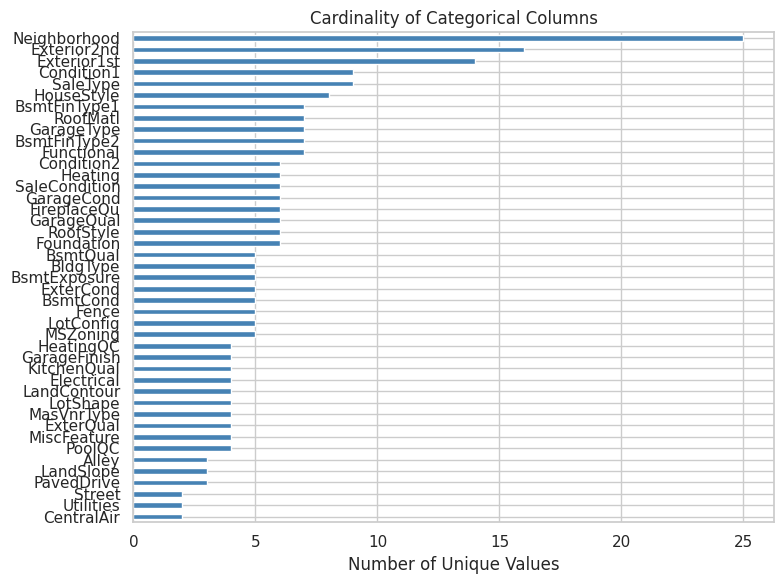

High-cardinality columns (>10 unique values): ['Neighborhood', 'Exterior2nd', 'Exterior1st']


In [ ]:
# Visualize cardinality as a horizontal bar chart
plt.figure(figsize=(8, 6))
cardinality.plot(kind='barh', color='steelblue')
plt.xlabel('Number of Unique Values')
plt.title('Cardinality of Categorical Columns')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Identify high-cardinality columns (threshold = 10)
high_card = cardinality[cardinality > 10]
print(f'High-cardinality columns (>10 unique values): {list(high_card.index)}')

In [ ]:
# Bucket nominal columns by cardinality: low (<=5), medium (6-15), high (>15)
buckets = {'low (<=5)': [], 'medium (6-15)': [], 'high (>15)': []}
for col, n in cardinality.items():
    if n <= 5:
        buckets['low (<=5)'].append(col)
    elif n <= 15:
        buckets['medium (6-15)'].append(col)
    else:
        buckets['high (>15)'].append(col)

for bucket, cols in buckets.items():
    print(f'{bucket}: {len(cols)} columns -> {cols}')

low (<=5): 24 columns -> ['BsmtQual', 'BldgType', 'BsmtExposure', 'ExterCond', 'BsmtCond', 'Fence', 'LotConfig', 'MSZoning', 'HeatingQC', 'GarageFinish', 'KitchenQual', 'Electrical', 'LandContour', 'LotShape', 'MasVnrType', 'ExterQual', 'MiscFeature', 'PoolQC', 'Alley', 'LandSlope', 'PavedDrive', 'Street', 'Utilities', 'CentralAir']
medium (6-15): 17 columns -> ['Exterior1st', 'Condition1', 'SaleType', 'HouseStyle', 'BsmtFinType1', 'RoofMatl', 'GarageType', 'BsmtFinType2', 'Functional', 'Condition2', 'Heating', 'SaleCondition', 'GarageCond', 'FireplaceQu', 'GarageQual', 'RoofStyle', 'Foundation']
high (>15): 2 columns -> ['Neighborhood', 'Exterior2nd']


### Instructor Notes — High Cardinality Check

**Code:** We compute the number of unique values per nominal column, sort descending, visualise as a horizontal bar chart, and bucket the columns into low (≤5 unique), medium (6–15), and high (>15) cardinality groups.

**Output:**
- `Neighborhood` 25 unique, `Exterior2nd` 16, `Exterior1st` 14, `SaleType` 9 ...
- `low (≤5):   24 columns`
- `medium (6-15):  7 columns`
- `high (>15):   2 columns → ['Neighborhood', 'Exterior2nd']`

**Why cardinality matters for OHE:** Each unique value in a nominal column becomes one new binary column. `Neighborhood` alone creates 25 OHE columns. In a real-world dataset with a column like "product SKU" that has 10,000 unique values, OHE would produce 10,000 new columns — making the feature matrix enormous and causing severe overfitting in linear models (more features than rows). Cardinality is the first thing to check before deciding whether OHE is appropriate.

**The threshold is a rule of thumb, not a law:** Columns with ≤5 unique values are safe candidates for OHE. Columns with 6–15 values are borderline — OHE is acceptable if the dataset is large enough. Columns with >15 values should be handled differently: target encoding (replace each category with the mean target value of its training rows), frequency encoding (replace with the count of occurrences), or grouping rare categories into an "Other" bucket before OHE.

**`Neighborhood` and `Exterior2nd` in the high bucket:** `Neighborhood` has strong price signal — houses in `NridgHt` average significantly higher than `OldTown`. Dropping it or OHE'ing it blindly would both lose information. For today's exercise we OHE it anyway, but a production-ready pipeline would likely use target encoding here.

**Discussion prompt:** "We OHE'd `Neighborhood` despite it having 25 unique values. How many OHE columns does that add, and what is the minimum frequency of the rarest `Neighborhood` category in 876 training rows?" → 25 OHE columns. If the rarest `Neighborhood` appears in only 3 training rows, the model has 3 data points to estimate its effect on price — an extremely unreliable estimate. Target encoding with cross-fitting would give a much better signal-to-noise ratio.

## 6) Numeric Scaling -- StandardScaler

In [ ]:
numeric_cols = X_train_enc.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns to scale: {len(numeric_cols)}')

scaler = StandardScaler()
X_train_enc[numeric_cols] = scaler.fit_transform(X_train_enc[numeric_cols])
X_val_enc[numeric_cols]   = scaler.transform(X_val_enc[numeric_cols])
X_test_enc[numeric_cols]  = scaler.transform(X_test_enc[numeric_cols])

print('StandardScaler applied.')

Numeric columns to scale: 257
StandardScaler applied.


### Instructor Notes — Numeric Scaling: StandardScaler

**Code:** We select all numeric columns from `X_train_enc` (which now includes the 10 ordinal-encoded quality columns and the 210 OHE binary columns alongside the original 37 numerics — 257 total), fit `StandardScaler` on `X_train_enc` only, and apply `.transform()` to all three splits in-place.

**Output:**
- `Numeric columns to scale: 257`
- `StandardScaler applied.`

**What StandardScaler does:** For each feature, it subtracts the training mean and divides by the training standard deviation: `z = (x − μ) / σ`. After scaling, every feature has mean ≈ 0 and std = 1.0 across the training set — regardless of its original scale. `LotArea` (range 215,000) and `OverallQual` (range 8) now live on the same numeric axis.

**Fit only on training data:** The scaler stores the `mean_` and `scale_` (std) computed from `X_train_enc`. These same values are used to transform `X_val_enc` and `X_test_enc`. If val or test rows have values outside the training range, the resulting z-scores will be outside [−3, 3], which is correct — it signals that the observation is unusually extreme compared to what the model was trained on.

**Why we scale binary OHE columns too:** Technically, a 0/1 column already has a bounded range and scaling it is unnecessary for tree models. For linear models and regularised models (Ridge, Lasso), including them in scaling is harmless and keeps the preprocessing logic uniform — one scaler for everything rather than conditional logic to skip certain columns. Simplicity is usually worth more than the tiny numerical benefit of skipping binary columns.

**Discussion prompt:** "The scaler is fitted on `X_train_enc`, not the original `X_train`. Does it matter that the training data was already OHE-encoded and ordinal-encoded before scaling?" → No — scaling is applied after encoding, not before. The scaler does not know or care whether a column came from OHE or was originally numeric. From its perspective, all 257 columns are just numbers with means and standard deviations. The order of operations (encode then scale) is correct: encoding is a categorical → numeric transform, scaling is a numeric → normalised numeric transform.

## 7) Verify -- Before vs After Scaling

In [ ]:
# Check mean and std of a few scaled numeric columns
X_train_enc[numeric_cols[:5]].describe().T[['mean', 'std']]

,mean,std
Id,-7.300097e-17,1.000571
MSSubClass,4.866731e-17,1.000571
LotFrontage,2.083569e-16,1.000571
LotArea,3.244487e-17,1.000571
OverallQual,-7.604267e-17,1.000571


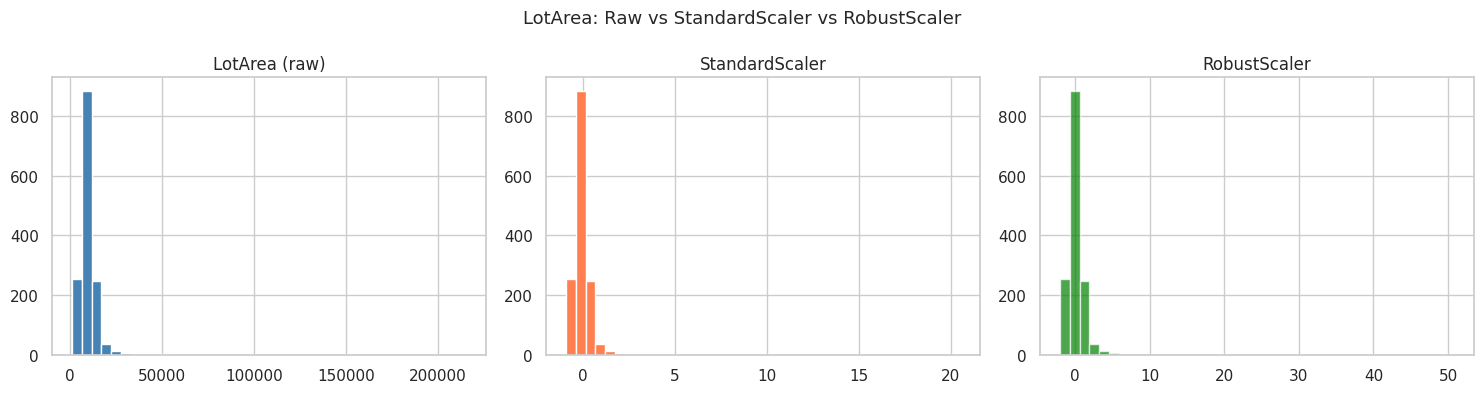

StandardScaler mean/std: -0.000 / 1.000
RobustScaler  mean/std: 0.257 / 2.465


In [ ]:
from sklearn.preprocessing import RobustScaler

# Compare StandardScaler vs RobustScaler on LotArea (has known outliers)
col = 'LotArea'
raw_values = df[col].dropna()

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

std_scaled = std_scaler.fit_transform(raw_values.values.reshape(-1, 1)).flatten()
rob_scaled = rob_scaler.fit_transform(raw_values.values.reshape(-1, 1)).flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(raw_values, bins=40, color='steelblue')
axes[0].set_title('LotArea (raw)')
axes[1].hist(std_scaled, bins=40, color='coral')
axes[1].set_title('StandardScaler')
axes[2].hist(rob_scaled, bins=40, color='green', alpha=0.7)
axes[2].set_title('RobustScaler')
plt.suptitle('LotArea: Raw vs StandardScaler vs RobustScaler', fontsize=13)
plt.tight_layout()
plt.show()
print('StandardScaler mean/std: {:.3f} / {:.3f}'.format(std_scaled.mean(), std_scaled.std()))
print('RobustScaler  mean/std: {:.3f} / {:.3f}'.format(rob_scaled.mean(), rob_scaled.std()))

In [ ]:
print('Final shapes:')
print(f'  X_train_enc: {X_train_enc.shape}')
print(f'  X_val_enc:   {X_val_enc.shape}')
print(f'  X_test_enc:  {X_test_enc.shape}')
print(f'  Any nulls: {X_train_enc.isnull().sum().sum()}')

Final shapes:
  X_train_enc: (876, 257)
  X_val_enc:   (292, 257)
  X_test_enc:  (292, 257)
  Any nulls: 0


In [ ]:
# Final dtype audit -- confirm zero object columns remain
dtypes_after = X_train_enc.dtypes.value_counts()
print('X_train_enc dtype counts:')
print(dtypes_after)
assert 'object' not in dtypes_after.index, 'ERROR: object columns still present!'
print('\nAll columns are numeric. Dataset is model-ready.')

X_train_enc dtype counts:
float64    257
Name: count, dtype: int64

All columns are numeric. Dataset is model-ready.


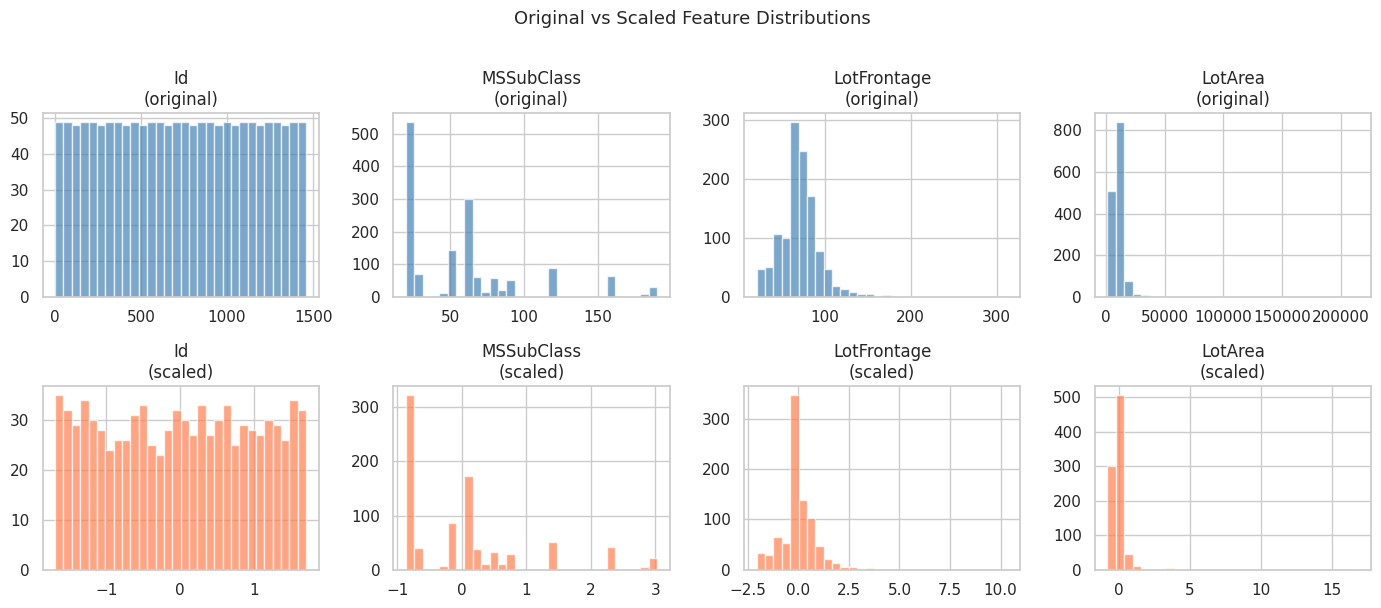

In [ ]:
# Distribution of a few scaled numeric features
sample_num_cols = numeric_cols[:4]
fig, axes = plt.subplots(2, len(sample_num_cols), figsize=(14, 6))

for j, col in enumerate(sample_num_cols):
    # Row 0: original distribution (from df)
    if col in df.columns:
        axes[0, j].hist(df[col].dropna(), bins=30, color='steelblue', alpha=0.7)
    axes[0, j].set_title(f'{col}\n(original)')

    # Row 1: scaled distribution
    axes[1, j].hist(X_train_enc[col], bins=30, color='coral', alpha=0.7)
    axes[1, j].set_title(f'{col}\n(scaled)')

plt.suptitle('Original vs Scaled Feature Distributions', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### Instructor Notes — Verify: Before vs After Scaling

**Code:** We check the mean and std of the first 5 scaled columns (expect ~0 and ~1), compare StandardScaler vs RobustScaler on `LotArea` with a three-panel histogram, confirm final shapes and null count, assert no object-dtype columns remain, and plot overlaid before/after histograms for 4 sample features.

**Output:**
- `Id: mean ≈ −7.30e−17, std ≈ 1.000571` (floating-point noise around exactly 0 and 1)
- `LotArea (raw)`: right-skewed with extreme outlier at ~215,000
- `StandardScaler`: compressed right tail, outlier appears as a z-score of ~8
- `RobustScaler`: std ≈ 2.465 (not constrained to 1), outlier still present but less dominant
- `Final shapes: X_train_enc (876, 257) | X_val_enc (292, 257) | X_test_enc (292, 257) | Any nulls: 0`
- `X_train_enc dtype counts: float64   257 — All columns are numeric. Dataset is model-ready.`

**Why StandardScaler vs RobustScaler on `LotArea`:** `LotArea` has a large outlier (~215,000 sq ft). StandardScaler's std is inflated by that outlier, which compresses all typical houses toward 0 on the scaled axis. RobustScaler uses the interquartile range (IQR) instead of std — it is immune to the outlier's influence on the scaling denominator. The RobustScaler histogram shows typical houses spread across a wider range, preserving more of their relative differences.

**The dtype audit is the final gate:** The assertion `'object' not in dtypes_after.index` catches any categorical column that was accidentally left unencoded. A silent object column would cause `LinearRegression` to raise a `ValueError` at fit time. Running this check here — before ever touching a model — means the crash happens at a known location with a clear message rather than deep inside an opaque training loop.

**The distribution plots confirm shape preservation:** The before and after histograms have identical shapes — scaling is a linear transformation that shifts and stretches but never changes the underlying distribution. This confirms nothing went wrong during scaling (no NaN introduction, no distribution distortion from a data bug).

**Discussion prompt:** "The final dataset has 257 features. Day 1 started with 80. Where did the extra 177 come from, and is a larger feature count always better?" → 10 ordinal + 210 OHE columns replaced 43 categorical columns (net +167), plus 37 original numerics retained = 257. More features are not always better — each added column gives the model more opportunity to find spurious correlations, especially with only 876 training rows. The ratio of rows to features (876/257 ≈ 3.4) is low for linear regression. In Week 3, we will learn to reduce this via feature selection and regularisation.

## 8) Summary

- Applied OrdinalEncoder to quality/condition columns with explicit ordering.
- Applied OneHotEncoder to nominal columns with `handle_unknown='ignore'`.
- Applied StandardScaler to all numeric columns, fit on train only.
- All splits encoded, scaled, and null-free.

**Next session (Day 3):** wrap all these steps into a scikit-learn Pipeline for reproducibility and deployment readiness.